In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

In [6]:
df = pd.read_csv("/content/US Stock Market Dataset.csv")

In [7]:
df.head()

,Unnamed: 0,Date,Natural_Gas_Price,Natural_Gas_Vol.,Crude_oil_Price,Crude_oil_Vol.,Copper_Price,Copper_Vol.,Bitcoin_Price,Bitcoin_Vol.,...,Berkshire_Price,Berkshire_Vol.,Netflix_Price,Netflix_Vol.,Amazon_Price,Amazon_Vol.,Meta_Price,Meta_Vol.,Gold_Price,Gold_Vol.
0,0,2/2/2024,2.079,NaN,72.28,NaN,3.8215,NaN,"43,194.70",42650,...,"5,89,498",10580,564.64,4030000,171.81,117220000,474.99,84710000,"2,053.70",NaN
1,1,1/2/2024,2.050,161340.0,73.82,577940.0,3.8535,NaN,"43,081.40",47690,...,"5,81,600",9780,567.51,3150000,159.28,66360000,394.78,25140000,"2,071.10",260920.0
2,2,31-01-2024,2.100,142860.0,75.85,344490.0,3.9060,NaN,"42,580.50",56480,...,"5,78,020",9720,564.11,4830000,155.20,49690000,390.14,20010000,"2,067.40",238370.0
3,3,30-01-2024,2.077,139750.0,77.82,347240.0,3.9110,NaN,"42,946.20",55130,...,"5,84,680",9750,562.85,6120000,159.00,42290000,400.06,18610000,"2,050.90",214590.0
4,4,29-01-2024,2.490,3590.0,76.78,331930.0,3.8790,NaN,"43,299.80",45230,...,"5,78,800",13850,575.79,6880000,161.26,42840000,401.02,17790000,"2,034.90",1780.0


In [8]:
df.drop('Unnamed: 0', axis=1, inplace=True)

In [9]:
df.isnull().sum()

,0
Date,0
Natural_Gas_Price,0
Natural_Gas_Vol.,4
Crude_oil_Price,0
Crude_oil_Vol.,23
Copper_Price,0
Copper_Vol.,37
Bitcoin_Price,0
Bitcoin_Vol.,0
Platinum_Price,0


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1013 entries, 0 to 1012
Data columns (total 38 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Date               1013 non-null   object 
 1   Natural_Gas_Price  1013 non-null   float64
 2   Natural_Gas_Vol.   1009 non-null   float64
 3   Crude_oil_Price    1013 non-null   float64
 4   Crude_oil_Vol.     990 non-null    float64
 5   Copper_Price       1013 non-null   float64
 6   Copper_Vol.        976 non-null    float64
 7   Bitcoin_Price      1013 non-null   object 
 8   Bitcoin_Vol.       1013 non-null   int64  
 9   Platinum_Price     1013 non-null   object 
 10  Platinum_Vol.      636 non-null    float64
 11  Ethereum_Price     1013 non-null   object 
 12  Ethereum_Vol.      1013 non-null   int64  
 13  S&P_500_Price      1013 non-null   object 
 14  Nasdaq_100_Price   1013 non-null   object 
 15  Nasdaq_100_Vol.    1012 non-null   float64
 16  Apple_Price        1013 

In [11]:
df.describe()

,Natural_Gas_Price,Natural_Gas_Vol.,Crude_oil_Price,Crude_oil_Vol.,Copper_Price,Copper_Vol.,Bitcoin_Vol.,Platinum_Vol.,Ethereum_Vol.,Nasdaq_100_Vol.,...,Nvidia_Price,Nvidia_Vol.,Berkshire_Vol.,Netflix_Price,Netflix_Vol.,Amazon_Price,Amazon_Vol.,Meta_Price,Meta_Vol.,Gold_Vol.
count,1013.000000,1009.000000,1013.000000,9.900000e+02,1013.000000,976.000000,1.013000e+03,636.000000,1.013000e+03,1.012000e+03,...,1013.000000,1.013000e+03,1013.000000,1013.000000,1.013000e+03,1013.000000,1.013000e+03,1013.000000,1.013000e+03,1011.000000
mean,3.726667,129091.932607,69.853475,3.571739e+05,3.726843,37606.752049,4.924137e+07,9082.515723,1.958002e+07,2.359978e+08,...,219.738065,4.629821e+07,2918.400790,422.035479,7.012043e+06,137.426209,7.452566e+07,252.151046,2.504895e+07,189442.393670
std,1.943030,64035.426727,21.986697,1.864309e+05,0.646524,39192.315092,3.251389e+08,8876.538587,1.469409e+08,8.363617e+07,...,128.668703,1.878815e+07,2715.637488,119.765870,6.788094e+06,27.321896,3.376809e+07,72.949246,1.635122e+07,104007.872337
min,1.482000,1200.000000,-37.630000,1.702000e+04,2.100500,10.000000,2.600000e+02,0.000000,7.518000e+04,6.857000e+07,...,49.100000,9.790000e+06,120.000000,166.370000,1.140000e+06,81.820000,2.162000e+07,88.910000,5.470000e+06,0.000000
25%,2.447000,88680.000000,54.760000,2.751800e+05,3.408000,380.000000,7.142000e+04,1120.000000,5.272300e+05,1.845550e+08,...,131.980000,3.348000e+07,760.000000,338.630000,3.780000e+06,114.770000,5.192000e+07,195.210000,1.612000e+07,142985.000000
50%,2.880000,125980.000000,72.910000,3.450350e+05,3.800500,31635.000000,1.288800e+05,6070.000000,9.665800e+05,2.239500e+08,...,179.130000,4.368000e+07,2040.000000,431.600000,5.380000e+06,142.300000,6.515000e+07,262.010000,2.107000e+07,181200.000000
75%,4.805000,164810.000000,82.810000,4.269225e+05,4.251500,70982.500000,3.860000e+05,15287.500000,3.670000e+06,2.646375e+08,...,272.470000,5.640000e+07,4090.000000,509.640000,7.890000e+06,161.060000,8.683000e+07,313.190000,2.903000e+07,231500.000000
max,9.647000,381970.000000,123.700000,1.770000e+06,4.937500,176040.000000,4.470000e+09,42830.000000,1.790000e+09,9.825600e+08,...,661.600000,1.534600e+08,13850.000000,691.690000,1.333900e+08,186.570000,3.113500e+08,474.990000,2.304100e+08,813410.000000


In [12]:
df['Natural_Gas_Vol.'] = df['Natural_Gas_Vol.'].fillna(df['Natural_Gas_Vol.'].mean())

In [13]:
df['Crude_oil_Vol.'] = df['Crude_oil_Vol.'].fillna(df['Crude_oil_Vol.'].mean())

In [14]:
df['Copper_Vol.'] = df['Copper_Vol.'].fillna(df['Copper_Vol.'].mean())

In [15]:
df['Platinum_Vol.'] = df['Platinum_Vol.'].fillna(df['Platinum_Vol.'].mean())

In [16]:
df['Nasdaq_100_Vol.'] = df['Nasdaq_100_Vol.'].fillna(df['Nasdaq_100_Vol.'].mean())

In [17]:
df['Silver_Vol.'] = df['Silver_Vol.'].fillna(df['Silver_Vol.'].mean())

In [18]:
df['Gold_Vol.'] = df['Gold_Vol.'].fillna(df['Gold_Vol.'].mean())

In [19]:
df['Date'] = pd.to_datetime(df['Date'], format='mixed', dayfirst=True)

In [20]:
df = df.sort_values('Date')

In [21]:
df['Days'] = (df['Date'] - df['Date'].min()).dt.days

In [22]:
df = df.sort_values('Date').reset_index(drop=True)
print(df['Date'].head())



0   2020-01-02
1   2020-01-03
2   2020-01-06
3   2020-01-07
4   2020-01-08
Name: Date, dtype: datetime64[ns]


In [23]:
df['S&P_500_Price'] = df['S&P_500_Price'].replace(r'[\$,]', '', regex=True).astype(float)
print(df['S&P_500_Price'].dtype)

float64


In [24]:
df['Nasdaq_100_Price'] = df['Nasdaq_100_Price'].replace(r'[\$,]', '', regex=True).astype(float)
print(df['Nasdaq_100_Price'].dtype)

float64


In [25]:
df['Bitcoin_Price'] = df['Bitcoin_Price'].replace(r'[\$,]', '', regex=True).astype(float)
df['BTC_Lag1'] = df['Bitcoin_Price'].shift(1)
df['BTC_7Day_Avg'] = df['Bitcoin_Price'].rolling(window=7).mean()
df.dropna(inplace=True)

In [26]:
x = df[['Bitcoin_Vol.','Google_Price','S&P_500_Price','Nasdaq_100_Price']]
y = df['Bitcoin_Price']

In [27]:
x_train,x_test,y_train,y_test = train_test_split(x,y, test_size = 0.4, random_state = 42)

In [28]:
model = LinearRegression()
model.fit(x_train, y_train)

LinearRegression()

In [29]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(x_train,y_train)

RandomForestRegressor(random_state=42)

In [30]:
rf_preds = rf_model.predict(x_test)

In [31]:
print(f"Random Forest R2 Score: {r2_score(y_test, rf_preds)}")
print(f"Random Forest MAE: {mean_absolute_error(y_test, rf_preds)}")

Random Forest R2 Score: 0.8914563193716492
Random Forest MAE: 3166.3271811414406


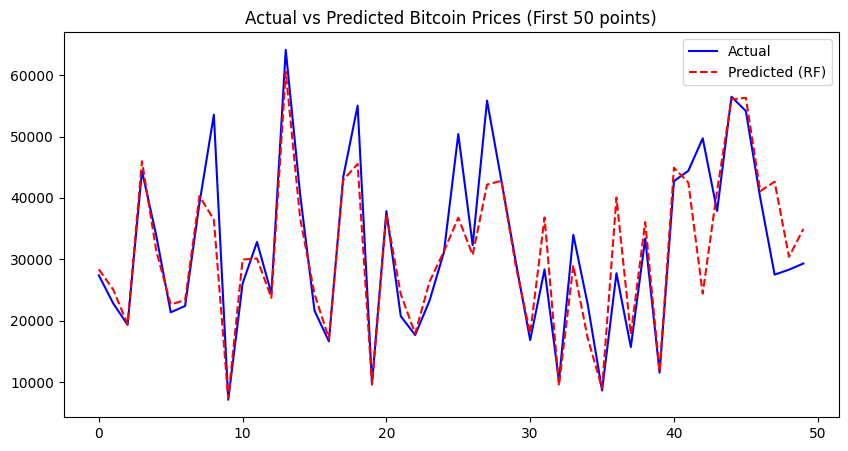

In [32]:
plt.figure(figsize=(10,5))
plt.plot(y_test.values[:50], label='Actual', color='blue')
plt.plot(rf_preds[:50], label='Predicted (RF)', color='red', linestyle='--')
plt.title('Actual vs Predicted Bitcoin Prices (First 50 points)')
plt.legend()
plt.show()


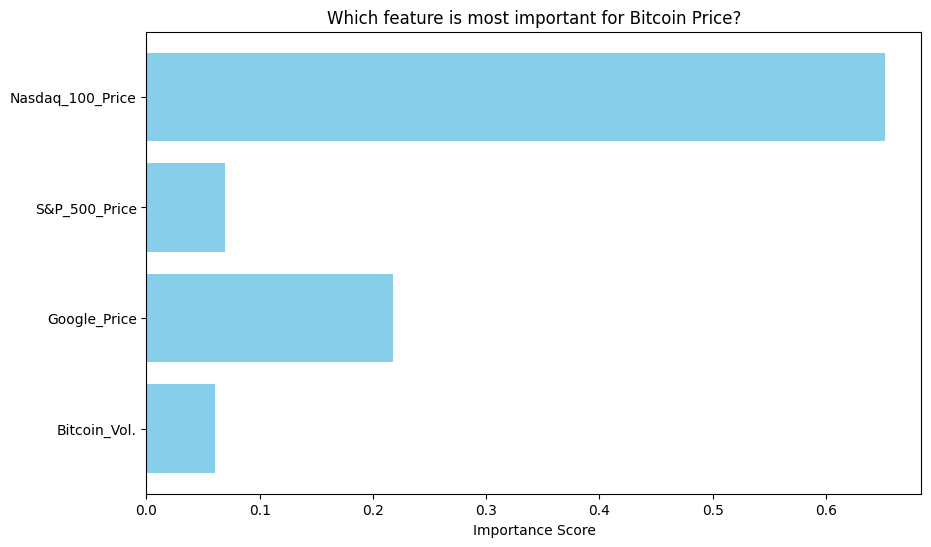

In [33]:
importances = rf_model.feature_importances_
feature_names = x.columns
plt.figure(figsize=(10, 6))
plt.barh(feature_names, importances, color='skyblue')
plt.xlabel('Importance Score')
plt.title('Which feature is most important for Bitcoin Price?')
plt.show()